##### 1. Load Libraries

In [7]:
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import os
import json

##### 2. Load and Add Target Columns
In this cell, data is read from the csv files in the "data" folder and imported as dataframes in Python. The target column is added, then encoded to a numerical value for the model. The target map is exported to keep track of which classification value is associated with which species. This export can be turned on/off based on the argument given to the function (shown in the code comment below). 

In [8]:
# dictionary for value insertion for target column
targets = {
    "1-9": "1:9 | Staph : PAO",
    "3-7": "3:7 | Staph : PAO",
    "5-5": "5:5 | Staph : PAO",
    "7-3": "7:3 | Staph : PAO",
    "9-1": "9:1 | Staph : PAO"
}

def read_all_csvs_to_df(folder_path):
    dataframes = []

    file_list = sorted(f for f in os.listdir(folder_path) if f.endswith(".csv"))

    for i, file_name in enumerate(file_list):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)

        if i != 0:
            df = df.iloc[1:].reset_index(drop=True)

        # adding the target column values based on the target dictionary above
        target_value = next((value for key, value in targets.items() if key in file_name), None)  

        if target_value is None:
            raise ValueError(f"No target mapping found for file: {file_name}")

        dataframes.append(df.assign(target=target_value))

    combined_df = pd.concat(dataframes, ignore_index=True)

    # label encoding for RF model 
    label_encoder = LabelEncoder()
    combined_df["target_encoded"] = label_encoder.fit_transform(combined_df["target"])

    # exporting target value map
    target_map = {
        str(original): int(encoded)
        for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
    }

    json_path = os.path.join(os.getcwd(), "target_encoding_map.json")
    with open(json_path, "w") as f:
        json.dump(target_map, f, indent=4)


    return combined_df


# accessing the main data folder
folder_path = os.path.join("..", "data", "mixed_ratio")
df = read_all_csvs_to_df(folder_path)

# for testing
#print(df.head())

C:\Users\jaira\AppData\Local\Temp\ipykernel_43912\3008409842.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframes.append(df.assign(target=target_value))
C:\Users\jaira\AppData\Local\Temp\ipykernel_43912\3008409842.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df["target_encoded"] = label_encoder.fit_transform(combined_df["target"])


##### 3. Label Data and Drop Target Column
In this cell, feature labels are changed and the target column is dropped. When importing the data from a csv into the dataframe, the feature labels (wavelengths) are changed to a numerical scale from 0 to the number of features/columns in the data. This remapping is exported as a json file to keep track of what is being looked at. This export can also be disabled through argument changes in the function. Since the logic of the previous cell required the string target column, it gets removed here instead of the previous cell.

In [9]:
def label_data(dataframe):
    target_idx = dataframe.columns.get_loc("target")
    feature_cols = dataframe.columns[:target_idx]

    feature_values = dataframe.iloc[0, :target_idx]
    feature_labels = range(1, len(feature_cols) + 1)

    clean_df = dataframe.iloc[1:].reset_index(drop=True).copy()
    clean_df = clean_df.rename(columns=dict(zip(feature_cols, feature_labels)))

    feature_map = dict(zip(feature_labels, feature_values))
    json_path = os.path.join(os.getcwd(), "feature_map.json")
    with open(json_path, "w") as f:
        json.dump(feature_map, f, indent=4)

    clean_df = clean_df.drop(columns=['target'], errors="ignore")

    return clean_df


#for testing
clean_df = label_data(df)
#print(clean_df.head())
#df.to_csv("file_bad.csv")

##### 4. Training the Model
In this cell, a function to train the model is being defined. Random state can be changed to a random number if need be, 42 was just an arbitrary value chosen for testing reproducibility. Actual model training will begin later when this function is called.

In [10]:
def train_model(
    df: pd.DataFrame,
    target_col: str = "target_encoded",
    test_size: float = 0.2,
    random_state: int = 42, # for reproducibility when testing
    n_estimators: int = 331,
    max_depth: int = 22
):
    """
    Splits the dataframe into train/test sets and trains a Random Forest classifier.

    Parameters:
        df (pd.DataFrame): Input dataframe containing features and target.
        target_col (str): Name of the encoded target column.
        test_size (float): Fraction of data to use for testing.
        random_state (int): Seed for reproducibility.
        n_estimators (int): Number of trees in the forest.
        max_depth (int or None): Maximum depth of each tree.

    Returns:
        model: Trained RandomForestClassifier
        X_train, X_test, y_train, y_test: Split datasets
    """
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe.")

    X = df.drop(columns=[target_col]) # features
    y = df[target_col] # target

    # training set (X,y), testing set (X,y)
    X_train, X_test, y_train, y_test = train_test_split( 
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # gave 100% accuracy before, changed to make sure not overfit. Kept for paper if need be
    """model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        n_jobs=-1
    )"""
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=4,
        min_samples_leaf=6,
        max_features="sqrt",
        random_state=random_state,
        n_jobs=-1,
        criterion="gini"
    )

    model.fit(X_train, y_train)

    return model, X_train, X_test, y_train, y_test

##### 5. Model Evaluation
Model evaluation functions are being defined here. The classification report export can be disabled by passing an argument to the function class. 

In [11]:
def get_unique_export_path(file_name):
    """Return a non-overwriting file path by appending a counter if needed."""
    base_name, ext = os.path.splitext(file_name)
    candidate = file_name
    counter = 1

    while os.path.exists(candidate):
        candidate = f"{base_name}_{counter}{ext}"
        counter += 1

    return candidate

def eval_model(model, X_test, y_test, report_filename="classification_report.csv"):
    """
    Evaluates a trained model on the test set.

    Parameters:
        model: Trained classifier
        X_test (pd.DataFrame): Test features
        y_test (pd.Series): True test labels

    Returns:
        results (dict): Dictionary of evaluation results
    """
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)
    report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).transpose()
    report_export_path = get_unique_export_path(report_filename)
    #report_df.to_csv(report_export_path, index=True)

    labels = sorted(set(y_test) | set(y_pred))
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("Confusion Matrix")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    print("Accuracy:", round(accuracy, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print(f"Classification report CSV saved to: {report_export_path}")
    print("\nClassification Report:")
    print(report)

    results = {
        "accuracy": accuracy,
        "weighted_f1": weighted_f1,
        "confusion_matrix": cm,
        "classification_report": report,
        "classification_report_csv_path": report_export_path,
    }

    return results

##### 7. Let's run it!
This is where all the functions written above come together. If you would like to save your model and use it later on for classification, set the save_model argument to True. 

Train Accuracy: 0.9486
Test Accuracy: 0.9301
Accuracy Gap: 0.0185

Cross-Validation Accuracy Scores: [0.7367 0.9666 0.8803 0.8968 0.7167]
CV Mean Accuracy: 0.8394
CV Std Dev: 0.0967


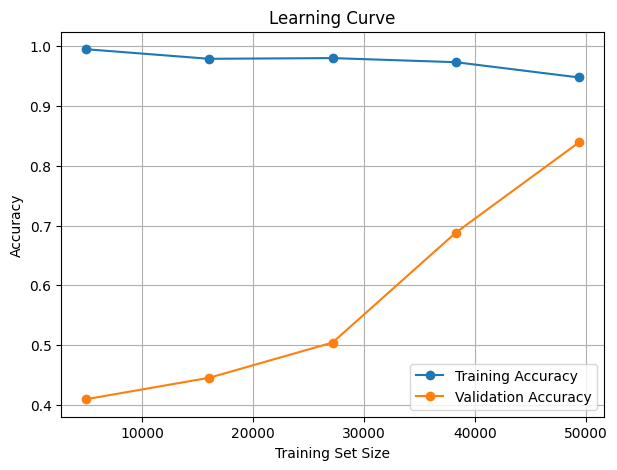


=== Evaluation on Clean Test Set ===


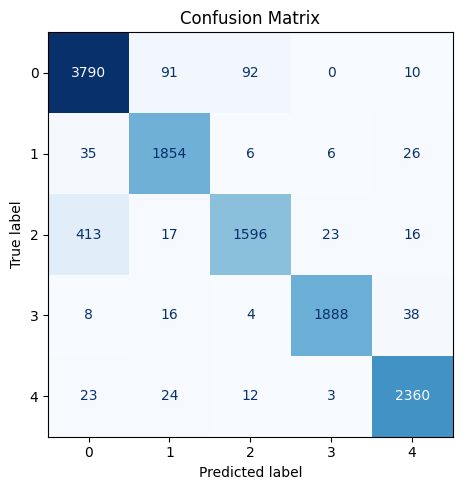

Accuracy: 0.9301
Weighted F1: 0.929
Classification report CSV saved to: classification_report_clean.csv

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3983
           1       0.93      0.96      0.94      1927
           2       0.93      0.77      0.85      2065
           3       0.98      0.97      0.97      1954
           4       0.96      0.97      0.97      2422

    accuracy                           0.93     12351
   macro avg       0.94      0.93      0.93     12351
weighted avg       0.93      0.93      0.93     12351



In [12]:
def main():
    """
    Main workflow for training and evaluating the Random Forest model.
    Assumes the dataframe 'clean_df' already exists in the notebook.
    """
    model, X_train, X_test, y_train, y_test = train_model(
        df=clean_df,
        target_col="target_encoded",
        test_size=0.2,
        random_state=42,
        n_estimators=200,
        max_depth=10
    )
    
    
    # Various methods to check for over fitting
    # ---------------------------------------------------
    # Compare training vs test performance
    # ---------------------------------------------------
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print("Train Accuracy:", round(train_acc, 4))
    print("Test Accuracy:", round(test_acc, 4))
    print("Accuracy Gap:", round(train_acc - test_acc, 4))

    # ---------------------------------------------------
    # Cross-validation performance
    # ---------------------------------------------------
    X_full = clean_df.drop(columns=["target_encoded"])
    y_full = clean_df["target_encoded"]

    cv_scores = cross_val_score(model, X_full, y_full, cv=5, scoring="accuracy")

    print("\nCross-Validation Accuracy Scores:", np.round(cv_scores, 4))
    print("CV Mean Accuracy:", round(cv_scores.mean(), 4))
    print("CV Std Dev:", round(cv_scores.std(), 4))

    # ---------------------------------------------------
    # Learning curve
    # ---------------------------------------------------
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_full,
        y_full,
        cv=5,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
    plt.plot(train_sizes, val_mean, marker='o', label="Validation Accuracy")
    plt.title("Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------------------------------------------------
    # Clean test evaluation (the only test set in this folder)
    # ---------------------------------------------------
    print("\n=== Evaluation on Clean Test Set ===")
    clean_results = eval_model(model, X_test, y_test, report_filename="classification_report_clean.csv")

    # Return the test split so the shared prediction export (next cell) can use it.
    return model, clean_results, X_test, y_test

model, clean_results, X_test, y_test = main()

##### Export Predictions for Model Comparison (Cochran's Q + McNemar)
- Writes this model's predictions on the **clean** 80/20 test set into the shared `model_predictions.csv`, aligned by `sample_id` (the original `clean_df` row index).
- Run all four notebooks (RF, XGBoost, CNN, Transformer), then run `cochrans_q_analysis.py` on `model_predictions.csv`.

In [13]:
# Export this model's predictions to the shared CSV consumed by cochrans_q_analysis.py.
# Every notebook writes to model_predictions.csv, aligned by sample_id (the original
# clean_df row index), so all four models are compared on the identical clean 80/20 test set.
def export_model_predictions(model_name, sample_ids, y_true_encoded, y_pred_encoded,
                             predictions_csv="model_predictions.csv",
                             label_map_path="target_encoding_map.json"):
    with open(label_map_path) as f:
        label_map = json.load(f)                       # {label_string: encoded_int}
    inv = {int(v): k for k, v in label_map.items()}

    new = pd.DataFrame({
        "sample_id": np.asarray(sample_ids, dtype=int),
        "true_label": [inv[int(v)] for v in np.asarray(y_true_encoded)],
        model_name: [inv[int(v)] for v in np.asarray(y_pred_encoded)],
    }).sort_values("sample_id").reset_index(drop=True)

    if os.path.exists(predictions_csv):
        shared = pd.read_csv(predictions_csv)
        if set(shared["sample_id"]) != set(new["sample_id"]):
            raise ValueError(
                f"{model_name}: sample_ids differ from existing {predictions_csv}. All models "
                "must use the same test split -- delete the CSV and rerun every notebook."
            )
        chk = shared[["sample_id", "true_label"]].merge(
            new[["sample_id", "true_label"]], on="sample_id", suffixes=("_a", "_b"))
        if not (chk["true_label_a"].astype(str) == chk["true_label_b"].astype(str)).all():
            raise ValueError(f"{model_name}: true_label disagrees with existing {predictions_csv}.")
        shared = shared.drop(columns=[model_name], errors="ignore")   # a re-run overwrites just this column
        merged = shared.merge(new[["sample_id", model_name]], on="sample_id", how="left")
    else:
        merged = new

    front = ["sample_id", "true_label"]
    merged = merged[front + [c for c in merged.columns if c not in front]]
    merged = merged.sort_values("sample_id").reset_index(drop=True)
    merged.to_csv(predictions_csv, index=False)
    print(f"[{model_name}] wrote clean-test predictions for {len(new)} samples -> {predictions_csv}")
    return merged


predictions_df = export_model_predictions(
    "RandomForest",
    sample_ids=X_test.index.to_numpy(),
    y_true_encoded=np.asarray(y_test),
    y_pred_encoded=model.predict(X_test),
)
predictions_df.head()

[RandomForest] wrote clean-test predictions for 12351 samples -> model_predictions.csv


,sample_id,true_label,XGBoost,CNN,Transformer,RandomForest
0,2,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO,9:1 | Staph : PAO,1:9 | Staph : PAO
1,9,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO
2,11,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO,9:1 | Staph : PAO,1:9 | Staph : PAO
3,13,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO
4,16,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO,9:1 | Staph : PAO,1:9 | Staph : PAO
